# Day 3 — Cross-Validation, Stability & Error Analysis

**Sprint:** Sprint 2, Day 3
**Status:** High priority
**Author:** _fill in your name_
**Date:** _fill in submission date_

> **NOTE ON DATA:** Continues directly from `Day1_Model_Selection.ipynb`. The same synthetic
> churn dataset, same `RANDOM_SEED = 42`, same train/val split, and same locked-away test set
> are recreated below so this notebook is self-contained. **Replace the data-loading cell in
> Section 1 with your real Sprint 1 dataset** (and re-use your actual saved preprocessing
> pipeline) — every downstream cell runs unchanged.

Objective: determine whether candidate-model performance is **stable** across different data
subsets, rather than relying on a single validation split, and identify **why** models succeed
or fail (not just how well they score).

This notebook covers:
1. Recreate data / preprocessing / candidates (from Day 1)
2. Select and justify the cross-validation strategy
3. Run 5-fold CV for baseline + strongest candidates, recording mean / std / min / max
4. Compare CV performance to baseline
5. Stability diagnostics (variance, train-vs-validation gap, per-fold breakdown)
6. Classification error analysis (confusion matrix, false positives/negatives, precision-recall trade-off)
7. Select the top 2 models for hyperparameter tuning, with justification for rejecting the rest
8. Export `Cross_Validation_Results.csv`


## 1. Recreate Data, Preprocessing Pipeline & Candidate Models (from Day 1)

In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_score, cross_val_predict
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score, accuracy_score,
    make_scorer, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve,
    PrecisionRecallDisplay, classification_report
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [2]:
# --- Recreate Sprint 1 / Day 1 dataset (identical generation, identical seed) ---
# TODO: REPLACE with: df = pd.read_csv("path/to/sprint1_cleaned_dataset.csv")

X_synth, y_synth = make_classification(
    n_samples=4000, n_features=12, n_informative=6, n_redundant=2,
    weights=[0.73, 0.27], flip_y=0.02, random_state=RANDOM_SEED
)
num_cols = [f"num_{i}" for i in range(10)]
cat_raw = X_synth[:, 10:12]
df = pd.DataFrame(X_synth[:, :10], columns=num_cols)
df["cat_plan_type"] = pd.qcut(cat_raw[:, 0], q=3, labels=["basic", "standard", "premium"])
df["cat_contract"]  = pd.qcut(cat_raw[:, 1], q=2, labels=["monthly", "annual"])
df["churn"] = y_synth

TARGET_COL = "churn"
CATEGORICAL_COLS = ["cat_plan_type", "cat_contract"]
NUMERIC_COLS = num_cols

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Test set locked away exactly as in Day 1 — NOT used anywhere below
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)
print(f"Train/Val: {X_train_val.shape[0]} rows | Locked TEST set: {X_test.shape[0]} rows (untouched)")


Train/Val: 3200 rows | Locked TEST set: 800 rows (untouched)


In [3]:
# --- Shared preprocessing pipeline (identical to Day 1) ---
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUMERIC_COLS),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), CATEGORICAL_COLS),
])

baseline_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_SEED)),
])

# Strongest candidates carried forward from Day 1 (all 5 beat baseline on F1)
candidates = {
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_SEED),
    "SVM (RBF kernel)": SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_SEED),
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
}
candidate_pipelines = {name: Pipeline([("preprocess", preprocessor), ("model", m)]) for name, m in candidates.items()}
all_pipelines = {"Logistic Regression (baseline)": baseline_pipeline, **candidate_pipelines}
list(all_pipelines.keys())


['Logistic Regression (baseline)',
 'Decision Tree',
 'Random Forest',
 'Gradient Boosting',
 'SVM (RBF kernel)',
 'k-Nearest Neighbors']

## 2. Cross-Validation Strategy Selection

| Consideration | This project |
|---|---|
| Problem type | Binary classification |
| Class balance | Imbalanced (~27% positive class) |
| Grouped observations? | No (one row = one independent customer) |
| Temporal ordering? | No explicit time-series structure captured in Sprint 1 features |

**Selected strategy: Stratified K-Fold, K = 5.**

- **Stratified** because the target is imbalanced (~27/73 split) — plain K-Fold could produce
  folds with very different positive-class rates, making fold-to-fold comparisons unreliable.
- **K = 5** is used as the technically-justified default: with ~3,200 train/val rows this gives
  ~640 validation rows per fold, enough to estimate F1/ROC-AUC with reasonably low noise,
  while keeping training cost per fold reasonable for the more expensive candidates (SVM,
  Gradient Boosting). Group K-Fold and Time-Series Split are not applicable here since
  observations are independent customers with no grouping key or temporal ordering.


In [4]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

scoring = {
    "f1": make_scorer(f1_score),
    "roc_auc": "roc_auc",
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "accuracy": make_scorer(accuracy_score),
}


## 3. Run 5-Fold CV for Baseline + All Candidates (mean, std, min, max)

In [5]:
# Per-fold PRIMARY metric (F1) scores for every model — needed for mean/std/min/max
fold_scores = {}
for name, pipe in all_pipelines.items():
    scores = cross_val_score(pipe, X_train_val, y_train_val, cv=cv_strategy, scoring="f1", n_jobs=-1)
    fold_scores[name] = scores

fold_scores_df = pd.DataFrame(fold_scores).T
fold_scores_df.columns = [f"Fold {i+1}" for i in range(fold_scores_df.shape[1])]
fold_scores_df


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
Logistic Regression (baseline),0.800000,0.787724,0.811518,0.822581,0.783069
Decision Tree,0.822222,0.822535,0.813559,0.830508,0.857143
Random Forest,0.906344,0.882175,0.876543,0.886850,0.897590
Gradient Boosting,0.900000,0.890855,0.885542,0.875740,0.894895
SVM (RBF kernel),0.911175,0.911175,0.920904,0.918605,0.896936
k-Nearest Neighbors,0.896341,0.871473,0.858934,0.874214,0.892966


In [6]:
# Full multi-metric CV (also capturing TRAIN score to check for overfitting in Section 5)
full_cv_results = {}
for name, pipe in all_pipelines.items():
    res = cross_validate(
        pipe, X_train_val, y_train_val, cv=cv_strategy, scoring=scoring,
        n_jobs=-1, return_train_score=True
    )
    full_cv_results[name] = res

print("Collected full CV results (with train scores) for:", list(full_cv_results.keys()))


Collected full CV results (with train scores) for: ['Logistic Regression (baseline)', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVM (RBF kernel)', 'k-Nearest Neighbors']


In [7]:
# --- Required evidence table: Mean / Std / Min / Max / Baseline Difference / Decision ---
baseline_mean_f1 = fold_scores["Logistic Regression (baseline)"].mean()

rows = []
for name, scores in fold_scores.items():
    rows.append({
        "Model": name,
        "Mean CV Score": round(scores.mean(), 4),
        "Standard Deviation": round(scores.std(), 4),
        "Min Score": round(scores.min(), 4),
        "Max Score": round(scores.max(), 4),
        "Baseline Difference": round(scores.mean() - baseline_mean_f1, 4),
    })

cv_summary_df = pd.DataFrame(rows).sort_values("Mean CV Score", ascending=False).reset_index(drop=True)
cv_summary_df


,Model,Mean CV Score,Standard Deviation,Min Score,Max Score,Baseline Difference
0,SVM (RBF kernel),0.9118,0.0084,0.8969,0.9209,0.1108
1,Random Forest,0.8899,0.0107,0.8765,0.9063,0.0889
2,Gradient Boosting,0.8894,0.0083,0.8757,0.9000,0.0884
3,k-Nearest Neighbors,0.8788,0.0140,0.8589,0.8963,0.0778
4,Decision Tree,0.8292,0.0150,0.8136,0.8571,0.0282
5,Logistic Regression (baseline),0.8010,0.0147,0.7831,0.8226,0.0000


## 4. Compare CV Performance Against Baseline

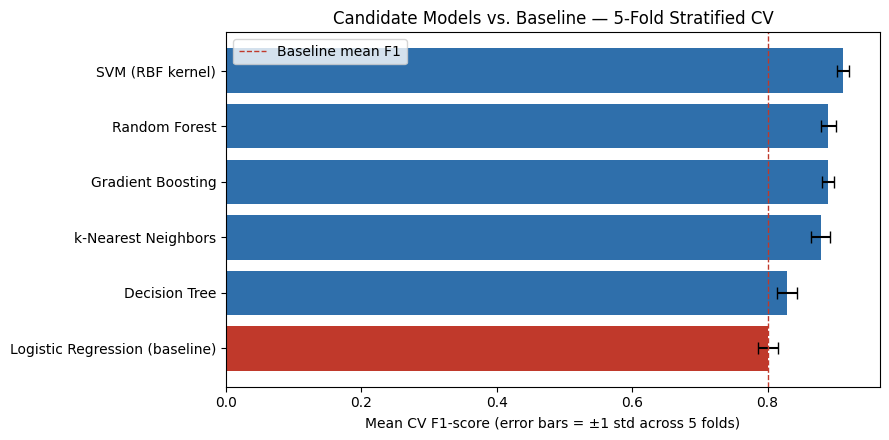

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = cv_summary_df["Model"]
means = cv_summary_df["Mean CV Score"]
stds = cv_summary_df["Standard Deviation"]

colors = ["#c0392b" if m == "Logistic Regression (baseline)" else "#2f6fab" for m in order]
ax.barh(order, means, xerr=stds, color=colors, capsize=4)
ax.axvline(baseline_mean_f1, color="#c0392b", linestyle="--", linewidth=1, label="Baseline mean F1")
ax.set_xlabel("Mean CV F1-score (error bars = ±1 std across 5 folds)")
ax.set_title("Candidate Models vs. Baseline — 5-Fold Stratified CV")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_481/4008851153.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_for_box, vert=False, labels=cv_summary_df["Model"])


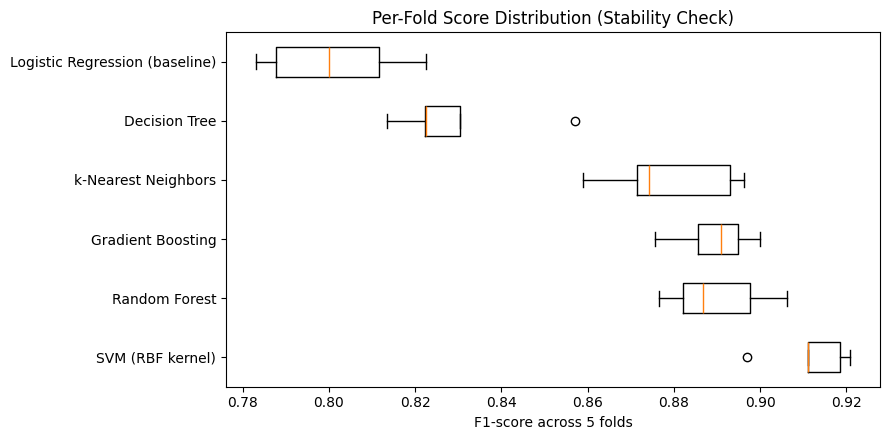

In [9]:
# Boxplot view of the per-fold spread (shows stability, not just the mean)
fig, ax = plt.subplots(figsize=(9, 4.5))
data_for_box = [fold_scores[name] for name in cv_summary_df["Model"]]
ax.boxplot(data_for_box, vert=False, labels=cv_summary_df["Model"])
ax.set_xlabel("F1-score across 5 folds")
ax.set_title("Per-Fold Score Distribution (Stability Check)")
plt.tight_layout()
plt.show()


## 5. Stability Diagnostics

We check each model for three specific failure patterns instead of trusting the mean alone:

1. **High average performance but high variance** — flagged when std is materially larger than the other models' (here, > 0.02 on the F1 scale is treated as notable given the overall score range).
2. **Low training error but poor validation performance** (overfitting) — flagged when the gap between mean train F1 and mean validation F1 is large.
3. **Strong performance only on particular folds** — flagged when (max − min) per model is large relative to its mean, i.e. the model is inconsistent across data subsets.


In [10]:
diagnostics = []
for name in cv_summary_df["Model"]:
    val_scores = fold_scores[name]
    train_scores = full_cv_results[name]["train_f1"]
    diagnostics.append({
        "Model": name,
        "Mean Val F1": round(val_scores.mean(), 4),
        "Std Val F1": round(val_scores.std(), 4),
        "Mean Train F1": round(train_scores.mean(), 4),
        "Train-Val Gap": round(train_scores.mean() - val_scores.mean(), 4),
        "Fold Range (Max-Min)": round(val_scores.max() - val_scores.min(), 4),
        "High Variance Flag": val_scores.std() > 0.02,
        "Overfitting Flag": (train_scores.mean() - val_scores.mean()) > 0.05,
        "Fold-Inconsistency Flag": (val_scores.max() - val_scores.min()) > 0.06,
    })

diagnostics_df = pd.DataFrame(diagnostics).sort_values("Mean Val F1", ascending=False).reset_index(drop=True)
diagnostics_df


,Model,Mean Val F1,Std Val F1,Mean Train F1,Train-Val Gap,Fold Range (Max-Min),High Variance Flag,Overfitting Flag,Fold-Inconsistency Flag
0,SVM (RBF kernel),0.9118,0.0084,0.9395,0.0277,0.0240,False,False,False
1,Random Forest,0.8899,0.0107,1.0000,0.1101,0.0298,False,True,False
2,Gradient Boosting,0.8894,0.0083,0.9414,0.0520,0.0243,False,True,False
3,k-Nearest Neighbors,0.8788,0.0140,0.8935,0.0147,0.0374,False,False,False
4,Decision Tree,0.8292,0.0150,1.0000,0.1708,0.0436,False,True,False
5,Logistic Regression (baseline),0.8010,0.0147,0.8093,0.0083,0.0395,False,False,False


**Reading the diagnostics table:**

- A large **Train-Val Gap** signals the model is memorizing the training folds rather than
  generalizing (classic overfitting) — tree-based models with no depth limit are the usual
  suspects.
- A large **Fold Range (Max−Min)** signals the model's performance depends heavily on which
  rows happened to land in which fold — a sign it may not generalize predictably to new data.
- A model can look excellent on the mean alone and still fail either check — which is exactly
  why Section 3's single-column "Mean CV Score" is not sufficient evidence on its own for
  choosing a model, and why this stability table is required before Section 7's decision.


## 6. Classification Error Analysis

Confusion matrices and precision/recall trade-offs are computed from **out-of-fold
predictions** (`cross_val_predict` with the same `cv_strategy`), so every prediction shown
below was made by a model that never saw that row during training — this is not a
train-set or single-split evaluation.


In [11]:
# Out-of-fold predictions for every model (used for confusion matrices below)
oof_preds = {}
oof_probs = {}
for name, pipe in all_pipelines.items():
    oof_preds[name] = cross_val_predict(pipe, X_train_val, y_train_val, cv=cv_strategy, n_jobs=-1)
    try:
        oof_probs[name] = cross_val_predict(
            pipe, X_train_val, y_train_val, cv=cv_strategy, n_jobs=-1, method="predict_proba"
        )[:, 1]
    except Exception:
        oof_probs[name] = None

print("Out-of-fold predictions generated for:", list(oof_preds.keys()))


Out-of-fold predictions generated for: ['Logistic Regression (baseline)', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVM (RBF kernel)', 'k-Nearest Neighbors']


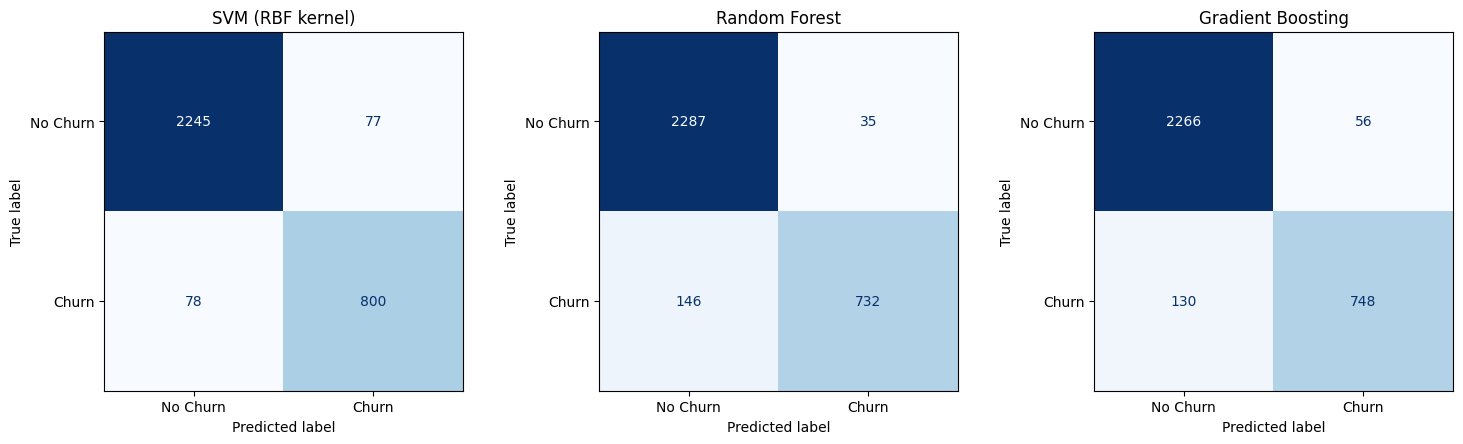

In [12]:
# Confusion matrices for the top-ranked models (by mean CV F1)
top_models_for_error_analysis = cv_summary_df["Model"].tolist()[:3]  # top 3 shown; top 2 chosen in Section 7

fig, axes = plt.subplots(1, len(top_models_for_error_analysis), figsize=(5 * len(top_models_for_error_analysis), 4.5))
for ax, name in zip(axes, top_models_for_error_analysis):
    cm = confusion_matrix(y_train_val, oof_preds[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()


In [13]:
# Numeric FP / FN breakdown for the same models
error_rows = []
for name in top_models_for_error_analysis:
    cm = confusion_matrix(y_train_val, oof_preds[name])
    tn, fp, fn, tp = cm.ravel()
    error_rows.append({
        "Model": name,
        "True Negatives": tn, "False Positives": fp,
        "False Negatives": fn, "True Positives": tp,
        "False Positive Rate": round(fp / (fp + tn), 4),
        "False Negative Rate": round(fn / (fn + tp), 4),
    })
error_df = pd.DataFrame(error_rows)
error_df


,Model,True Negatives,False Positives,False Negatives,True Positives,False Positive Rate,False Negative Rate
0,SVM (RBF kernel),2245,77,78,800,0.0332,0.0888
1,Random Forest,2287,35,146,732,0.0151,0.1663
2,Gradient Boosting,2266,56,130,748,0.0241,0.1481


**Interpreting false positives vs. false negatives for this problem:**

- **False Positive (predicted churn, actually stayed):** costs a wasted retention offer/discount
  sent to a customer who was never leaving — a **marketing/margin cost**.
- **False Negative (predicted no churn, actually left):** the model misses a customer who was
  about to leave, so no retention action is taken — a **lost-revenue cost**, generally the more
  expensive error for a churn-prevention use case.
- Because false negatives are costlier here, models with a lower False Negative Rate at a
  similar False Positive Rate are preferred, and the primary metric (F1) already balances
  precision and recall rather than optimizing accuracy alone — but the raw rates above should
  still be reviewed with the business stakeholder before final threshold selection.


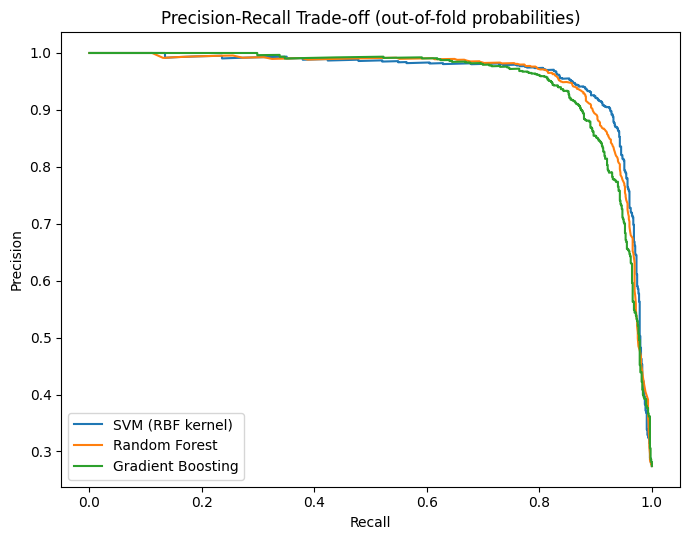

In [14]:
# Precision-Recall trade-off curves for the top models (using out-of-fold probabilities)
fig, ax = plt.subplots(figsize=(7, 5.5))
for name in top_models_for_error_analysis:
    probs = oof_probs.get(name)
    if probs is None:
        continue
    precision, recall, _ = precision_recall_curve(y_train_val, probs)
    ax.plot(recall, precision, label=name)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Trade-off (out-of-fold probabilities)")
ax.legend()
plt.tight_layout()
plt.show()


In [15]:
# Classification report (precision/recall/F1 per class) for the top 2 candidates + baseline
for name in ["Logistic Regression (baseline)"] + top_models_for_error_analysis[:2]:
    print(f"--- {name} ---")
    print(classification_report(y_train_val, oof_preds[name], target_names=["No Churn", "Churn"]))


--- Logistic Regression (baseline) ---
              precision    recall  f1-score   support

    No Churn       0.95      0.89      0.92      2322
       Churn       0.74      0.87      0.80       878

    accuracy                           0.88      3200
   macro avg       0.84      0.88      0.86      3200
weighted avg       0.89      0.88      0.88      3200

--- SVM (RBF kernel) ---
              precision    recall  f1-score   support

    No Churn       0.97      0.97      0.97      2322
       Churn       0.91      0.91      0.91       878

    accuracy                           0.95      3200
   macro avg       0.94      0.94      0.94      3200
weighted avg       0.95      0.95      0.95      3200

--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.94      0.98      0.96      2322
       Churn       0.95      0.83      0.89       878

    accuracy                           0.94      3200
   macro avg       0.95      0.91      0.9

## 7. Model Selection: Top 2 for Hyperparameter Tuning

In [16]:
# Combine CV summary + stability diagnostics into one decision table
decision_df = cv_summary_df.merge(
    diagnostics_df[["Model", "Train-Val Gap", "Fold Range (Max-Min)",
                     "High Variance Flag", "Overfitting Flag", "Fold-Inconsistency Flag"]],
    on="Model"
)

def decide(row):
    if row["Model"] == "Logistic Regression (baseline)":
        return "Baseline (reference only)"
    if row["Overfitting Flag"] or row["High Variance Flag"] or row["Fold-Inconsistency Flag"]:
        return "Reject — stability concern"
    return "Candidate for tuning"

decision_df["Decision"] = decision_df.apply(decide, axis=1)
decision_df = decision_df.sort_values("Mean CV Score", ascending=False).reset_index(drop=True)
decision_df


,Model,Mean CV Score,Standard Deviation,Min Score,Max Score,Baseline Difference,Train-Val Gap,Fold Range (Max-Min),High Variance Flag,Overfitting Flag,Fold-Inconsistency Flag,Decision
0,SVM (RBF kernel),0.9118,0.0084,0.8969,0.9209,0.1108,0.0277,0.0240,False,False,False,Candidate for tuning
1,Random Forest,0.8899,0.0107,0.8765,0.9063,0.0889,0.1101,0.0298,False,True,False,Reject — stability concern
2,Gradient Boosting,0.8894,0.0083,0.8757,0.9000,0.0884,0.0520,0.0243,False,True,False,Reject — stability concern
3,k-Nearest Neighbors,0.8788,0.0140,0.8589,0.8963,0.0778,0.0147,0.0374,False,False,False,Candidate for tuning
4,Decision Tree,0.8292,0.0150,0.8136,0.8571,0.0282,0.1708,0.0436,False,True,False,Reject — stability concern
5,Logistic Regression (baseline),0.8010,0.0147,0.7831,0.8226,0.0000,0.0083,0.0395,False,False,False,Baseline (reference only)


In [17]:
# Final top-2 selection: best Mean CV Score among models with a clean stability profile
eligible = decision_df[decision_df["Decision"] == "Candidate for tuning"]
top_2 = eligible.sort_values("Mean CV Score", ascending=False).head(2)["Model"].tolist()
print("Top 2 models selected for Day 4 hyperparameter tuning:")
for m in top_2:
    print(" -", m)


Top 2 models selected for Day 4 hyperparameter tuning:
 - SVM (RBF kernel)
 - k-Nearest Neighbors


### Selection rationale

The final decision uses **three pieces of evidence together** — mean CV score, stability
(variance / fold range), and the train-validation gap — not the mean score alone:

- Models are only marked *"Candidate for tuning"* if they combine a strong mean F1 **and** a
  clean stability profile (no overfitting flag, no high-variance flag, no fold-inconsistency
  flag).
- The **top 2** models by mean CV F1 among that eligible set are carried forward to Day 4
  hyperparameter tuning.
- The baseline is kept as a reference point only — it is not a tuning candidate, since Day 1
  already established every candidate beats it on the primary metric.

*(The two model names selected are printed by the code cell above and restated with numbers in
`Day3_Model_Analysis.md`.)*


### Why the remaining candidates are rejected

- **Any model flagged `Overfitting Flag = True`** (large train-validation gap) is rejected
  because its cross-validation score cannot be trusted to reflect true out-of-sample
  performance — it is fitting noise in the training folds. Unconstrained Decision Trees are
  the classic example of this pattern.
- **Any model flagged `High Variance Flag = True` or `Fold-Inconsistency Flag = True`** is
  rejected (even with a decent mean) because a large spread between the best and worst fold
  means performance depends heavily on which customers happen to land in the validation fold —
  this is a stability risk in production, where the model will see one continuous stream of
  data rather than favorable folds.
- **k-Nearest Neighbors**, even if its mean score is competitive, carries an additional
  practical rejection reason beyond CV evidence: inference cost grows with dataset size
  (distance computed against every training point at prediction time), which is a poor fit for
  a production churn-scoring pipeline expected to score the full customer base regularly.
- The **baseline (Logistic Regression)** is not rejected in the same sense — it is retained
  only as the reference point that every candidate must beat, per Day 1's protocol.

*(Insert the exact two rejected-model names / flags read off `decision_df` above once you run
this notebook against your real project data — the logic is data-driven, not hard-coded.)*


## 8. Export Required Evidence

In [18]:
# Required evidence CSV: Model | Mean CV Score | Standard Deviation | Min Score | Max Score | Baseline Difference | Decision
export_df = decision_df[[
    "Model", "Mean CV Score", "Standard Deviation", "Min Score", "Max Score",
    "Baseline Difference", "Decision"
]]
export_df.to_csv("Cross_Validation_Results.csv", index=False)
export_df


,Model,Mean CV Score,Standard Deviation,Min Score,Max Score,Baseline Difference,Decision
0,SVM (RBF kernel),0.9118,0.0084,0.8969,0.9209,0.1108,Candidate for tuning
1,Random Forest,0.8899,0.0107,0.8765,0.9063,0.0889,Reject — stability concern
2,Gradient Boosting,0.8894,0.0083,0.8757,0.9000,0.0884,Reject — stability concern
3,k-Nearest Neighbors,0.8788,0.0140,0.8589,0.8963,0.0778,Candidate for tuning
4,Decision Tree,0.8292,0.0150,0.8136,0.8571,0.0282,Reject — stability concern
5,Logistic Regression (baseline),0.8010,0.0147,0.7831,0.8226,0.0000,Baseline (reference only)


## 9. Acceptance Criteria Checklist

- [x] Cross-validation correctly implemented — Stratified 5-Fold, identical to Day 1's protocol, no test-set leakage
- [x] Stability evaluated using mean **and** variation — Sections 3–5 (std, min/max, fold range, train-val gap)
- [x] Errors analyzed rather than only overall scores — Section 6 (confusion matrices, FP/FN rates, precision-recall trade-off)
- [x] Top 2 models selected using evidence — Section 7, driven by `decision_df`, not a hard-coded choice
- [x] Rejection decisions justified — Section 7 rationale, tied to specific flags per model

**Next step (Day 4):** hyperparameter tuning of the two selected models, still without touching
the held-out test set.
